# Week 1: Course Introduction — Digital Health and AI in Medical Applications
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Navigate Google Colab: create, edit, and run code and markdown cells
2. Review Python fundamentals with clinical data examples
3. Use NumPy for patient data array operations and statistics
4. Create clinical visualizations with matplotlib
5. Load and explore real ECG data from the MIT-BIH Arrhythmia Database

**Tools:** Google Colab + Gemini AI
**Dataset:** MIT-BIH Arrhythmia Database (PhysioNet, via `wfdb`)
**Estimated Time:** 40-50 minutes

---

> **Clinical Scenario (Red Thread):** A Taiwan ER doctor uses a phone app — AI
> identifies STEMI in 10 seconds, and the patient gets catheterization in 90
> minutes. A decade ago this required a cardiologist on call. Today we set up
> the tools and learn the fundamentals that make this kind of AI possible.


## 0. Environment Setup & Welcome

Welcome to your first hands-on lab! Google Colab is a free, browser-based
Jupyter notebook environment that requires no local installation. It comes
pre-loaded with Python, NumPy, pandas, and matplotlib. We only need to install
one additional library: **wfdb** for reading PhysioNet ECG databases.

**What you will do in this notebook:**
1. Learn Colab basics (markdown + code cells)
2. Meet Gemini AI (your AI study partner)
3. Review Python with clinical examples
4. Work with NumPy arrays of patient data
5. Visualize clinical data with matplotlib
6. Load and explore REAL ECG recordings from MIT-BIH


In [1]:
# ============================================================
# Section 0a: Install additional libraries
# ============================================================
!pip install wfdb==4.1.2 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 8.8 MB/s eta 0:00:00


In [2]:
!pip install --upgrade wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: wfdb
    Found existing installation: wfdb 4.1.2
    Uninstalling wfdb-4.1.2:
      Successfully uninstalled wfdb-4.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio

In [3]:
# ============================================================
# Section 0b: Import libraries and verify
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Plotting style for consistent, clean visuals
plt.style.use('seaborn-v0_8-whitegrid')

# Print versions to confirm everything works
print("All libraries loaded successfully!")
print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")
print(f"Matplotlib version: {__import__('matplotlib').__version__}")

# wfdb will be imported later when we need it (Section 7)
print("\nwfdb will be imported in Section 7 for ECG data loading.")
print("\nYou are ready to begin!")


All libraries loaded successfully!
NumPy version:      2.0.2
Pandas version:     3.0.1
Matplotlib version: 3.10.0

wfdb will be imported in Section 7 for ECG data loading.

You are ready to begin!


## 1. Markdown Tutorial — Your Digital Lab Notebook

In Colab, there are two types of cells:
- **Code cells**: Run Python code (click the play button or press Shift+Enter)
- **Markdown cells**: Write formatted text, like this cell!

Markdown is your **digital lab notebook**. Use it to document your experiments,
explain your thinking, and annotate results — just like writing in a physical
lab notebook, but with formatting superpowers.

### Quick Reference: Markdown Syntax

| Syntax | Result |
|--------|--------|
| `# Heading 1` | Large heading |
| `## Heading 2` | Medium heading |
| `**bold text**` | **bold text** |
| `*italic text*` | *italic text* |
| `- item` | Bulleted list |
| `1. item` | Numbered list |
| `` `code` `` | Inline code |
| `$E=mc^2$` | LaTeX math: $E=mc^2$ |

### Example: Clinical Note in Markdown

**Patient:** 52-year-old male
**Chief Complaint:** Chest pain, onset 30 minutes ago
**Vitals:** HR 95 bpm, BP 142/88 mmHg, SpO2 97%
**Assessment:** Rule out STEMI — *stat ECG ordered*


In [4]:
# ============================================================
# Section 1: This is a code cell — it runs Python!
# ============================================================
print("This is a code cell - it runs Python!")
print("Press Shift+Enter to execute this cell.")
print("The output appears directly below.")

# Try changing the message and re-running!
patient_name = "Mr. Chen"
print(f"\nWelcome to BME 7451, {patient_name}!")


This is a code cell - it runs Python!
Press Shift+Enter to execute this cell.
The output appears directly below.

Welcome to BME 7451, Mr. Chen!


### Try it yourself!

**Double-click this cell** to see the raw markdown source. Then press
Shift+Enter to render it back. Try adding:
- Your name in **bold**
- A favorite equation in LaTeX: `$...$`
- A bulleted list of 3 things you want to learn this semester


## 2. Gemini AI — Hello Medical AI

Google Colab includes **Gemini AI** — think of it as a knowledgeable study
partner who can explain concepts, generate code, and help you think through
problems. Throughout this course, we will use Gemini for:
- Explaining medical AI concepts in plain language
- Generating and debugging code
- Discussing clinical implications of AI results

> **Important:** Always verify Gemini's output! AI assistants can make mistakes.
> The `google.colab.ai` module is only available in the Colab environment.


In [5]:
# ============================================================
# Section 2: Gemini AI — Ask About STEMI
# ============================================================
try:
    from google.colab import ai

    response = ai.generate_text(
        "Explain what STEMI is in simple terms for a biomedical "
        "engineering student. Include why rapid diagnosis matters. "
        "Keep it under 150 words."
    )
    print("Gemini's Answer:")
    print("=" * 50)
    print(response)

except Exception as e:
    print(f"Gemini not available: {e}")
    print("\nManual answer:")
    print("STEMI (ST-Elevation Myocardial Infarction) is a severe heart")
    print("attack where a coronary artery is completely blocked by a")
    print("blood clot. The 'ST-Elevation' refers to a specific pattern")
    print("visible on an ECG tracing.")
    print("\nWhy rapid diagnosis matters:")
    print("  - Heart muscle dies at ~1 billion cells per hour")
    print("  - 'Door-to-balloon' time target: < 90 minutes")
    print("  - Every 30 minutes of delay increases mortality by ~7.5%")
    print("  - AI can read an ECG in 10 seconds vs waiting for a cardiologist")
    print("\nThis is why AI-assisted ECG interpretation in the ER")
    print("and ambulance can literally save lives.")


Gemini's Answer:
**STEMI (ST-Elevation Myocardial Infarction)** is the most severe type of heart attack. It occurs when a major coronary artery, responsible for supplying blood to the heart muscle, becomes **completely blocked**, usually by a blood clot (thrombus) forming on ruptured atherosclerotic plaque. This total occlusion starves a significant portion of the heart muscle (myocardium) of oxygen, leading to its rapid death (infarction).

**Rapid diagnosis is critical because "time is muscle."** Every minute the artery remains blocked, more heart tissue dies irreversibly. This loss severely impairs the heart's pumping ability, leading to heart failure, dangerous arrhythmias, and increased mortality. Prompt ECG diagnosis (ST elevation) allows immediate reperfusion therapies (e.g., angioplasty) to restore blood flow, minimizing damage and dramatically improving patient survival and long-term heart function.


## 3. GitHub & Copilot Setup Guide

While Google Colab + Gemini is our **primary platform** for this course,
GitHub Copilot is an excellent AI coding assistant for larger projects in
VS Code. As a student, you can get it **free** via the GitHub Student
Developer Pack.

### Step 1: Create a GitHub Account
1. Go to [github.com](https://github.com) and sign up
2. Use your **university email** (e.g., `@gs.ncku.edu.tw`)
3. Choose a professional username (you will use this for your portfolio)

### Step 2: Apply for the Student Developer Pack
1. Go to [education.github.com/pack](https://education.github.com/pack)
2. Click "Get your Pack"
3. Verify your student status with your university email
4. Approval typically takes 1-3 business days

### Step 3: Enable GitHub Copilot
1. Once approved, go to [github.com/settings/copilot](https://github.com/settings/copilot)
2. Enable Copilot (free with Student Pack)
3. Install the **GitHub Copilot** extension in VS Code

### Tool Comparison

| Tool | Best For | Access | Environment |
|------|---------|--------|-------------|
| Google Colab + Gemini | Course exercises, experiments | Free (Google account) | Browser |
| GitHub Copilot | Larger projects, IDE workflows | Free (Student Developer Pack) | VS Code |

> **For this course**, all assignments and labs use Google Colab. Copilot is
> optional but highly recommended for your research projects.


### Version Control Basics (Preview)

Git is the standard tool for tracking code changes — like "Track Changes"
in Word, but for code. You will use it throughout your career. For now,
just remember these key commands:

```bash
git init           # Start tracking a folder
git add .          # Stage all changes
git commit -m "msg" # Save a snapshot
git push           # Upload to GitHub
```

We will practice Git in later weeks. For now, focus on setting up your
GitHub account and getting the Student Developer Pack.


## 4. Python Refresher — Clinical Context

Let's review Python fundamentals using **clinical data examples**. If you
already know Python well, skim through quickly and focus on the clinical
context — these patterns will recur throughout the course.

**Why clinical context?** Every variable, list, and function in this course
connects to real medical data. Getting comfortable with clinical terminology
in code now will make the rest of the semester much smoother.


In [6]:
# ============================================================
# Section 4a: Variables with clinical context
# ============================================================
# Patient demographics
patient_name = "Mr. Lin"
patient_age = 52
patient_weight_kg = 78.5
patient_height_m = 1.72
is_diabetic = True

print("--- Patient Record ---")
print(f"Name:     {patient_name}")
print(f"Age:      {patient_age} years")
print(f"Weight:   {patient_weight_kg} kg")
print(f"Height:   {patient_height_m} m")
print(f"Diabetic: {is_diabetic}")

# Vital signs
heart_rate = 95       # bpm
systolic_bp = 142     # mmHg
diastolic_bp = 88     # mmHg
spo2 = 97             # percent
temperature = 37.2    # Celsius

print(f"\n--- Vital Signs ---")
print(f"Heart Rate:  {heart_rate} bpm")
print(f"Blood Pressure: {systolic_bp}/{diastolic_bp} mmHg")
print(f"SpO2:        {spo2}%")
print(f"Temperature: {temperature} C")


--- Patient Record ---
Name:     Mr. Lin
Age:      52 years
Weight:   78.5 kg
Height:   1.72 m
Diabetic: True

--- Vital Signs ---
Heart Rate:  95 bpm
Blood Pressure: 142/88 mmHg
SpO2:        97%
Temperature: 37.2 C


In [7]:
# ============================================================
# Section 4b: Lists — tracking vitals over time
# ============================================================
# Heart rate readings every hour (8 readings from a patient monitor)
vitals = [72, 75, 68, 80, 77, 65, 90, 85]
print(f"Heart rate readings: {vitals}")
print(f"Number of readings:  {len(vitals)}")
print(f"First reading:       {vitals[0]} bpm")
print(f"Last reading:        {vitals[-1]} bpm")

# Check for abnormal readings
print("\nChecking for abnormal heart rates...")
for i, hr in enumerate(vitals):
    if hr > 100:
        print(f"  ALERT: Reading {i+1} = {hr} bpm (tachycardia!)")
    elif hr < 60:
        print(f"  WARNING: Reading {i+1} = {hr} bpm (bradycardia)")
    else:
        print(f"  Reading {i+1} = {hr} bpm (normal)")

# Basic statistics with built-in functions
print(f"\nAverage HR: {sum(vitals)/len(vitals):.1f} bpm")
print(f"Min HR:     {min(vitals)} bpm")
print(f"Max HR:     {max(vitals)} bpm")


Heart rate readings: [72, 75, 68, 80, 77, 65, 90, 85]
Number of readings:  8
First reading:       72 bpm
Last reading:        85 bpm

Checking for abnormal heart rates...
  Reading 1 = 72 bpm (normal)
  Reading 2 = 75 bpm (normal)
  Reading 3 = 68 bpm (normal)
  Reading 4 = 80 bpm (normal)
  Reading 5 = 77 bpm (normal)
  Reading 6 = 65 bpm (normal)
  Reading 7 = 90 bpm (normal)
  Reading 8 = 85 bpm (normal)

Average HR: 76.5 bpm
Min HR:     65 bpm
Max HR:     90 bpm


In [8]:
# ============================================================
# Section 4c: Functions — reusable clinical calculations
# ============================================================
def calculate_bmi(weight_kg, height_m):
    """Calculate Body Mass Index and return category."""
    bmi = weight_kg / (height_m ** 2)
    if bmi < 18.5:
        category = "Underweight"
    elif bmi < 24.0:
        category = "Normal"
    elif bmi < 27.0:
        category = "Overweight"
    else:
        category = "Obese"
    return bmi, category


def classify_bp(systolic, diastolic):
    """Classify blood pressure according to clinical guidelines."""
    if systolic < 120 and diastolic < 80:
        return "Normal"
    elif systolic < 130 and diastolic < 80:
        return "Elevated"
    elif systolic < 140 or diastolic < 90:
        return "Hypertension Stage 1"
    else:
        return "Hypertension Stage 2"


# Test our clinical functions
bmi, bmi_cat = calculate_bmi(patient_weight_kg, patient_height_m)
bp_class = classify_bp(systolic_bp, diastolic_bp)

print(f"Patient: {patient_name}")
print(f"  BMI: {bmi:.1f} kg/m^2 ({bmi_cat})")
print(f"  BP:  {systolic_bp}/{diastolic_bp} mmHg ({bp_class})")

# Test with different patients
print("\n--- Batch Screening ---")
patients = [
    ("Ms. Wang", 55.0, 1.60, 118, 75),
    ("Mr. Chen", 92.0, 1.75, 155, 95),
    ("Ms. Liu",  48.0, 1.58, 105, 68),
]
for name, w, h, sbp, dbp in patients:
    b, cat = calculate_bmi(w, h)
    bp = classify_bp(sbp, dbp)
    print(f"  {name}: BMI={b:.1f} ({cat}), BP={sbp}/{dbp} ({bp})")


Patient: Mr. Lin
  BMI: 26.5 kg/m^2 (Overweight)
  BP:  142/88 mmHg (Hypertension Stage 1)

--- Batch Screening ---
  Ms. Wang: BMI=21.5 (Normal), BP=118/75 (Normal)
  Mr. Chen: BMI=30.0 (Obese), BP=155/95 (Hypertension Stage 2)
  Ms. Liu: BMI=19.2 (Normal), BP=105/68 (Normal)


In [9]:
# ============================================================
# Section 4d: Dictionaries — structured patient records
# ============================================================
patient_record = {
    "id": "NCKU-2024-0001",
    "name": "Mr. Lin",
    "age": 52,
    "sex": "Male",
    "chief_complaint": "Chest pain, onset 30 min ago",
    "vitals": {
        "heart_rate": 95,
        "systolic_bp": 142,
        "diastolic_bp": 88,
        "spo2": 97,
        "temperature": 37.2
    },
    "history": ["Hypertension", "Type 2 Diabetes", "Hyperlipidemia"],
    "medications": ["Metformin 500mg", "Amlodipine 5mg", "Atorvastatin 20mg"],
    "ecg_ordered": True
}

print("--- Electronic Health Record ---")
print(f"Patient ID: {patient_record['id']}")
print(f"Name:       {patient_record['name']}, {patient_record['age']}y {patient_record['sex']}")
print(f"CC:         {patient_record['chief_complaint']}")
print(f"\nVitals:")
for key, val in patient_record['vitals'].items():
    print(f"  {key}: {val}")
print(f"\nHistory:     {', '.join(patient_record['history'])}")
print(f"Medications: {', '.join(patient_record['medications'])}")
print(f"ECG ordered: {patient_record['ecg_ordered']}")


--- Electronic Health Record ---
Patient ID: NCKU-2024-0001
Name:       Mr. Lin, 52y Male
CC:         Chest pain, onset 30 min ago

Vitals:
  heart_rate: 95
  systolic_bp: 142
  diastolic_bp: 88
  spo2: 97
  temperature: 37.2

History:     Hypertension, Type 2 Diabetes, Hyperlipidemia
Medications: Metformin 500mg, Amlodipine 5mg, Atorvastatin 20mg
ECG ordered: True


## 5. NumPy for Patient Data

NumPy is the foundation of scientific computing in Python. In medical AI,
nearly ALL data passes through NumPy arrays at some point:
- ECG signals = 1D arrays
- Patient feature tables = 2D arrays
- Medical images = 3D arrays (height x width x channels)
- Batches of images = 4D arrays

Let's practice with clinical data.


In [10]:
# ============================================================
# Section 5a: 1D arrays — heart rate monitoring
# ============================================================
# 8 heart rate readings from a patient monitor
heart_rates = np.array([72, 75, 68, 80, 77, 65, 90, 85])

print("Heart Rate Array")
print(f"  Data:  {heart_rates}")
print(f"  Shape: {heart_rates.shape}")
print(f"  Dtype: {heart_rates.dtype}")

# NumPy statistics — much faster than Python loops for large data
print(f"\nStatistics:")
print(f"  Mean:   {np.mean(heart_rates):.1f} bpm")
print(f"  Std:    {np.std(heart_rates):.1f} bpm")
print(f"  Min:    {np.min(heart_rates)} bpm")
print(f"  Max:    {np.max(heart_rates)} bpm")
print(f"  Median: {np.median(heart_rates):.1f} bpm")

# Boolean indexing — find elevated readings
elevated = heart_rates[heart_rates > 80]
print(f"\nElevated readings (>80 bpm): {elevated}")
print(f"  Count: {len(elevated)} out of {len(heart_rates)}")
print(f"  Percentage: {len(elevated)/len(heart_rates)*100:.1f}%")


Heart Rate Array
  Data:  [72 75 68 80 77 65 90 85]
  Shape: (8,)
  Dtype: int64

Statistics:
  Mean:   76.5 bpm
  Std:    7.9 bpm
  Min:    65 bpm
  Max:    90 bpm
  Median: 76.0 bpm

Elevated readings (>80 bpm): [90 85]
  Count: 2 out of 8
  Percentage: 25.0%


In [11]:
# ============================================================
# Section 5b: 2D arrays — patient feature matrix
# ============================================================
# 5 patients x 4 features: Age, Heart Rate, Systolic BP, SpO2
patient_data = np.array([
    [52, 95, 142, 97],   # Patient 1 — our STEMI suspect
    [34, 72, 118, 99],   # Patient 2 — healthy young adult
    [68, 88, 158, 94],   # Patient 3 — elderly hypertensive
    [45, 110, 130, 96],  # Patient 4 — tachycardic
    [71, 62, 125, 95],   # Patient 5 — elderly normal
])
feature_names = ["Age", "HR (bpm)", "SBP (mmHg)", "SpO2 (%)"]

print(f"Patient data matrix shape: {patient_data.shape}")
print(f"  {patient_data.shape[0]} patients x {patient_data.shape[1]} features\n")

# Column-wise statistics (axis=0 means along rows, giving per-feature stats)
print("Per-Feature Statistics:")
print(f"  {'Feature':<15} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print(f"  {'-'*45}")
for i, name in enumerate(feature_names):
    col = patient_data[:, i]
    print(f"  {name:<15} {np.mean(col):>8.1f} {np.std(col):>8.1f} "
          f"{np.min(col):>6.0f} {np.max(col):>6.0f}")

# Find the patient with highest blood pressure
max_bp_idx = np.argmax(patient_data[:, 2])
print(f"\nHighest BP: Patient {max_bp_idx + 1} "
      f"(SBP = {patient_data[max_bp_idx, 2]:.0f} mmHg)")

# Find patients with SpO2 below 96% (potential hypoxemia)
low_spo2 = np.where(patient_data[:, 3] < 96)[0]
print(f"Low SpO2 (<96%): Patients {[p+1 for p in low_spo2]}")


Patient data matrix shape: (5, 4)
  5 patients x 4 features

Per-Feature Statistics:
  Feature             Mean      Std    Min    Max
  ---------------------------------------------
  Age                 54.0     13.9     34     71
  HR (bpm)            85.4     16.9     62    110
  SBP (mmHg)         134.6     14.1    118    158
  SpO2 (%)            96.2      1.7     94     99

Highest BP: Patient 3 (SBP = 158 mmHg)
Low SpO2 (<96%): Patients [np.int64(3), np.int64(5)]


## 6. matplotlib — Clinical Visualization

Visualization is essential in medical AI. You need to:
- Plot physiological signals (ECG, EEG, vital sign trends)
- Visualize model predictions and performance metrics
- Create publication-quality figures for papers and presentations

Let's build up from simple plots to multi-panel clinical dashboards.


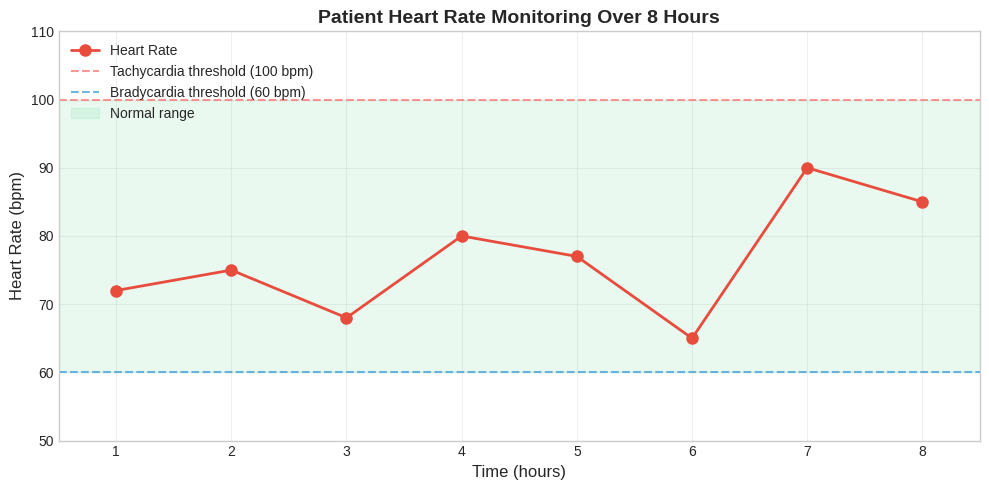

This is exactly how a bedside monitor displays trends.
The nurse would be alerted if HR crosses the red or blue thresholds.


In [12]:
# ============================================================
# Section 6a: Line plot — heart rate over time
# ============================================================
hours = np.arange(1, 9)  # 8 hourly readings
hr_readings = np.array([72, 75, 68, 80, 77, 65, 90, 85])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, hr_readings, 'o-', color='#E74C3C', linewidth=2,
        markersize=8, label='Heart Rate')

# Add tachycardia threshold
ax.axhline(y=100, color='#FF6B6B', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Tachycardia threshold (100 bpm)')
ax.axhline(y=60, color='#3498DB', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Bradycardia threshold (60 bpm)')

# Shade normal range
ax.axhspan(60, 100, alpha=0.1, color='#2ECC71', label='Normal range')

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Heart Rate (bpm)', fontsize=12)
ax.set_title('Patient Heart Rate Monitoring Over 8 Hours',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.set_xlim(0.5, 8.5)
ax.set_ylim(50, 110)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("This is exactly how a bedside monitor displays trends.")
print("The nurse would be alerted if HR crosses the red or blue thresholds.")


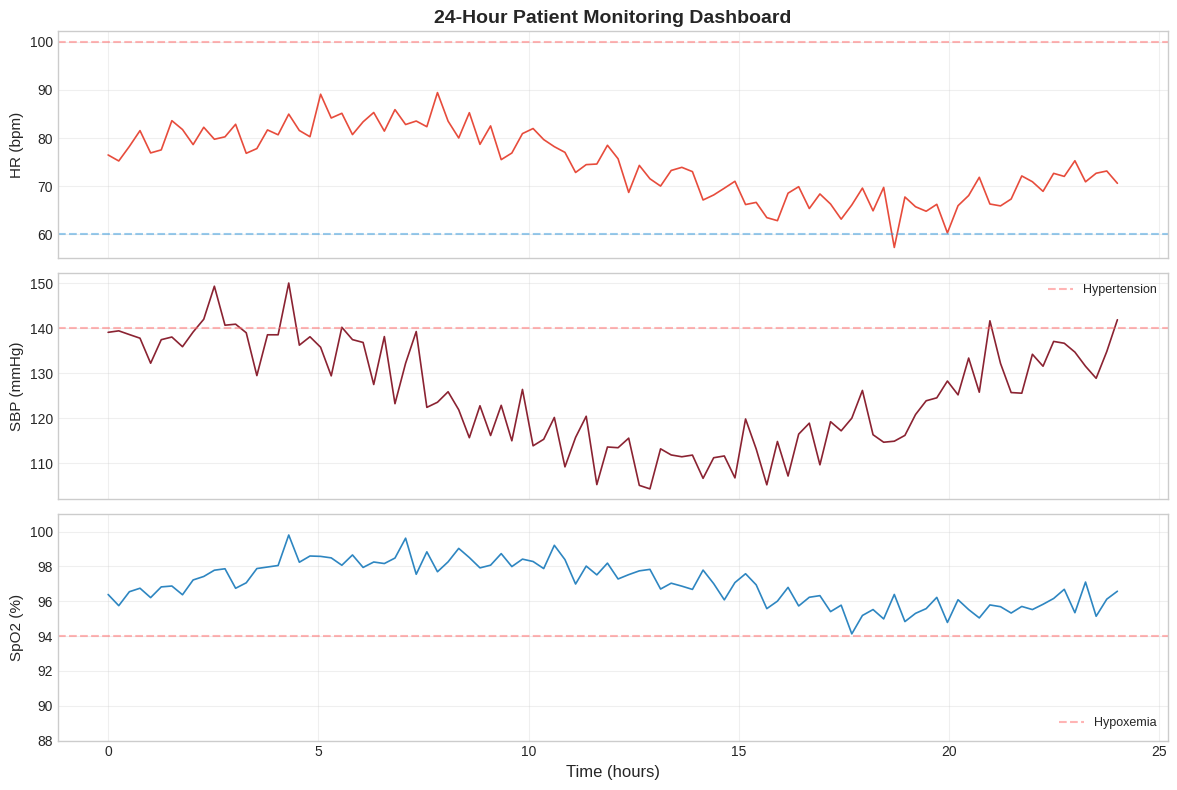

A clinical dashboard like this gives nurses an at-a-glance view.
AI can analyze these trends to predict deterioration BEFORE it happens.


In [13]:
# ============================================================
# Section 6b: Subplots — multi-signal clinical dashboard
# ============================================================
# Simulate 24 hours of continuous monitoring
np.random.seed(42)
time_hours = np.linspace(0, 24, 96)  # Reading every 15 min

hr_signal = 75 + 10 * np.sin(2 * np.pi * time_hours / 24) + np.random.normal(0, 3, 96)
sbp_signal = 125 + 15 * np.sin(2 * np.pi * time_hours / 24 + 1) + np.random.normal(0, 5, 96)
spo2_signal = 97 + 1.5 * np.sin(2 * np.pi * time_hours / 24 - 0.5) + np.random.normal(0, 0.5, 96)
spo2_signal = np.clip(spo2_signal, 88, 100)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Heart Rate
axes[0].plot(time_hours, hr_signal, color='#E74C3C', linewidth=1.2)
axes[0].axhline(y=100, color='#FF6B6B', linestyle='--', alpha=0.5)
axes[0].axhline(y=60, color='#3498DB', linestyle='--', alpha=0.5)
axes[0].set_ylabel('HR (bpm)', fontsize=11)
axes[0].set_title('24-Hour Patient Monitoring Dashboard', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Blood Pressure
axes[1].plot(time_hours, sbp_signal, color='#8B2332', linewidth=1.2)
axes[1].axhline(y=140, color='#FF6B6B', linestyle='--', alpha=0.5, label='Hypertension')
axes[1].set_ylabel('SBP (mmHg)', fontsize=11)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

# SpO2
axes[2].plot(time_hours, spo2_signal, color='#2E86C1', linewidth=1.2)
axes[2].axhline(y=94, color='#FF6B6B', linestyle='--', alpha=0.5, label='Hypoxemia')
axes[2].set_ylabel('SpO2 (%)', fontsize=11)
axes[2].set_xlabel('Time (hours)', fontsize=12)
axes[2].legend(fontsize=9, loc='lower right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(88, 101)

plt.tight_layout()
plt.show()

print("A clinical dashboard like this gives nurses an at-a-glance view.")
print("AI can analyze these trends to predict deterioration BEFORE it happens.")


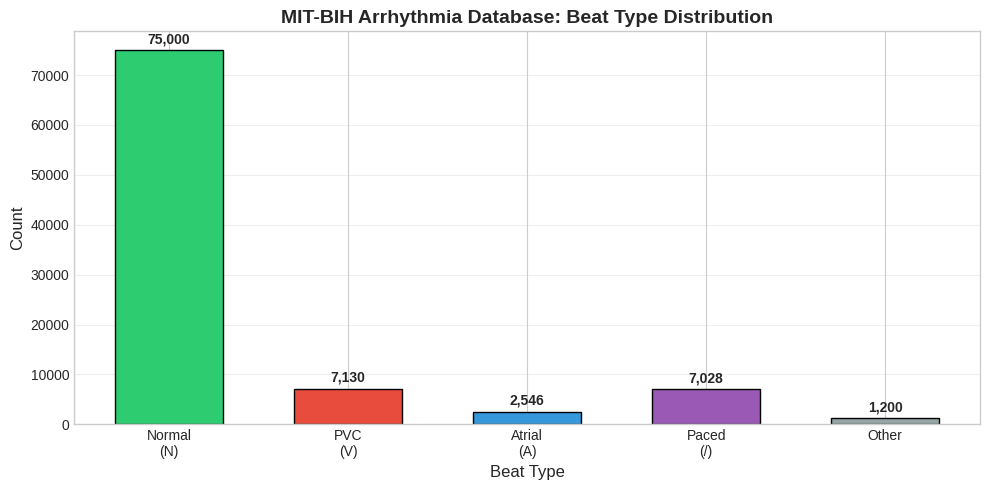

Notice the class imbalance: Normal beats vastly outnumber abnormal ones.
This is a major challenge in medical AI - we will address it in Week 4.


In [14]:
# ============================================================
# Section 6c: Bar chart — beat type distribution (ECG preview)
# ============================================================
# Preview of what we will see in MIT-BIH ECG data
beat_types = ['Normal\n(N)', 'PVC\n(V)', 'Atrial\n(A)', 'Paced\n(/)' , 'Other']
beat_counts = [75000, 7130, 2546, 7028, 1200]
colors = ['#2ECC71', '#E74C3C', '#3498DB', '#9B59B6', '#95A5A6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(beat_types, beat_counts, color=colors, edgecolor='black', width=0.6)

# Add count labels on top of bars
for bar, count in zip(bars, beat_counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 800,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Beat Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MIT-BIH Arrhythmia Database: Beat Type Distribution',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Notice the class imbalance: Normal beats vastly outnumber abnormal ones.")
print("This is a major challenge in medical AI - we will address it in Week 4.")


Clinical Patient Table:
Patient_ID  Age  HR  SBP  SpO2   Risk
      P001   52  95  142    97   High
      P002   34  72  118    99    Low
      P003   68  88  158    94   High
      P004   45 110  130    96 Medium
      P005   71  62  125    95 Medium
      P006   29  75  112    99    Low
      P007   55 102  148    93   High
      P008   63  78  135    97 Medium
      P009   40  68  120    98    Low
      P010   58  91  140    96 Medium

High-risk patients: 3
Patient_ID  Age  HR  SBP  SpO2
      P001   52  95  142    97
      P003   68  88  158    94
      P007   55 102  148    93


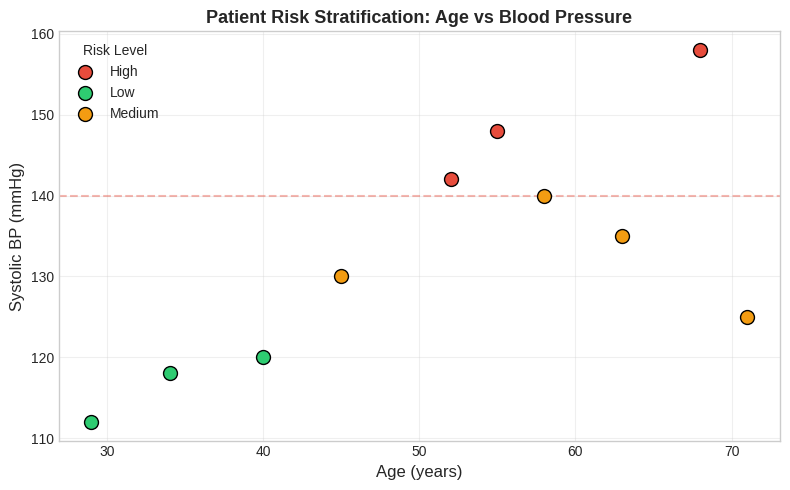

This scatter plot shows a pattern: older patients with higher BP tend
to be higher risk. ML algorithms learn these patterns automatically.


In [15]:
# ============================================================
# Section 6d: Mini pipeline — DataFrame + filter + plot
# ============================================================
# Create a clinical DataFrame
df = pd.DataFrame({
    'Patient_ID': [f'P{i:03d}' for i in range(1, 11)],
    'Age': [52, 34, 68, 45, 71, 29, 55, 63, 40, 58],
    'HR': [95, 72, 88, 110, 62, 75, 102, 78, 68, 91],
    'SBP': [142, 118, 158, 130, 125, 112, 148, 135, 120, 140],
    'SpO2': [97, 99, 94, 96, 95, 99, 93, 97, 98, 96],
    'Risk': ['High', 'Low', 'High', 'Medium', 'Medium',
             'Low', 'High', 'Medium', 'Low', 'Medium']
})

print("Clinical Patient Table:")
print(df.to_string(index=False))

# Filter high-risk patients
high_risk = df[df['Risk'] == 'High']
print(f"\nHigh-risk patients: {len(high_risk)}")
print(high_risk[['Patient_ID', 'Age', 'HR', 'SBP', 'SpO2']].to_string(index=False))

# Scatter plot: Age vs SBP, colored by risk
fig, ax = plt.subplots(figsize=(8, 5))
risk_colors = {'Low': '#2ECC71', 'Medium': '#F39C12', 'High': '#E74C3C'}
for risk, group in df.groupby('Risk'):
    ax.scatter(group['Age'], group['SBP'], c=risk_colors[risk],
               s=100, label=risk, edgecolors='black', zorder=5)
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Systolic BP (mmHg)', fontsize=12)
ax.set_title('Patient Risk Stratification: Age vs Blood Pressure',
             fontsize=13, fontweight='bold')
ax.legend(title='Risk Level', fontsize=10)
ax.axhline(y=140, color='#E74C3C', linestyle='--', alpha=0.4, label='Hypertension')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("This scatter plot shows a pattern: older patients with higher BP tend")
print("to be higher risk. ML algorithms learn these patterns automatically.")


## 7. Load Real ECG Data from MIT-BIH

The **MIT-BIH Arrhythmia Database** is one of the most important datasets in
medical AI history. Created in 1980 at MIT and Boston's Beth Israel Hospital,
it contains 48 half-hour excerpts of two-channel ambulatory ECG recordings from
47 subjects. It has been used in **thousands** of research papers and is the
benchmark for arrhythmia detection algorithms.

**Key facts:**
- 48 records, each ~30 minutes long
- 2 channels (usually MLII and V1)
- Sampling rate: 360 Hz
- Over 110,000 annotated beats
- Freely available on PhysioNet

We use the `wfdb` library to load records directly from PhysioNet's servers.


In [16]:
# ============================================================
# Section 7: Load MIT-BIH Record 100
# ============================================================
import wfdb

USE_SYNTHETIC = False

try:
    # Load record 100 from MIT-BIH (a classic benchmark record)
    print("Loading MIT-BIH record 100 from PhysioNet...")
    record = wfdb.rdrecord('100', pn_dir='mitdb')

    print(f"Record loaded successfully!")
    print(f"  Signal shape:    {record.p_signal.shape} (samples x channels)")
    print(f"  Sampling rate:   {record.fs} Hz")
    print(f"  Signal names:    {record.sig_name}")
    print(f"  Duration:        {record.p_signal.shape[0] / record.fs:.0f} seconds "
          f"({record.p_signal.shape[0] / record.fs / 60:.1f} minutes)")
    print(f"  Units:           {record.units}")

except Exception as e:
    print(f"Could not load from PhysioNet: {e}")
    print("\nUsing synthetic ECG data as fallback...")
    USE_SYNTHETIC = True

    # Generate synthetic ECG-like signal
    np.random.seed(42)
    fs = 360  # Match MIT-BIH sampling rate
    duration = 30 * 60  # 30 minutes in seconds
    n_samples = fs * duration
    t = np.arange(n_samples) / fs

    # Simple synthetic ECG: sum of Gaussians for P, QRS, T waves
    # Repeated at ~72 bpm (period = 0.833s = 300 samples at 360 Hz)
    period = int(fs * 60 / 72)  # samples per beat
    single_beat = np.zeros(period)

    # P wave
    p_center = int(period * 0.15)
    single_beat += 0.15 * np.exp(-0.5 * ((np.arange(period) - p_center) / (period * 0.02)) ** 2)
    # QRS complex
    qrs_center = int(period * 0.35)
    single_beat += 1.0 * np.exp(-0.5 * ((np.arange(period) - qrs_center) / (period * 0.01)) ** 2)
    single_beat -= 0.2 * np.exp(-0.5 * ((np.arange(period) - qrs_center + int(period*0.03)) / (period * 0.008)) ** 2)
    # T wave
    t_center = int(period * 0.55)
    single_beat += 0.3 * np.exp(-0.5 * ((np.arange(period) - t_center) / (period * 0.04)) ** 2)

    # Tile the beat to fill duration
    n_beats = n_samples // period + 1
    ecg_full = np.tile(single_beat, n_beats)[:n_samples]
    ecg_full += np.random.normal(0, 0.05, n_samples)  # Add noise

    # Create a mock record-like object
    class MockRecord:
        def __init__(self):
            self.p_signal = np.column_stack([ecg_full, ecg_full * 0.7])
            self.fs = fs
            self.sig_name = ['MLII', 'V1']
            self.units = ['mV', 'mV']

    record = MockRecord()
    print(f"  Signal shape:    {record.p_signal.shape}")
    print(f"  Sampling rate:   {record.fs} Hz")
    print(f"  Signal names:    {record.sig_name}")
    print(f"  Duration:        {record.p_signal.shape[0] / record.fs:.0f} seconds")


Loading MIT-BIH record 100 from PhysioNet...
Record loaded successfully!
  Signal shape:    (650000, 2) (samples x channels)
  Sampling rate:   360 Hz
  Signal names:    ['MLII', 'V5']
  Duration:        1806 seconds (30.1 minutes)
  Units:           ['mV', 'mV']


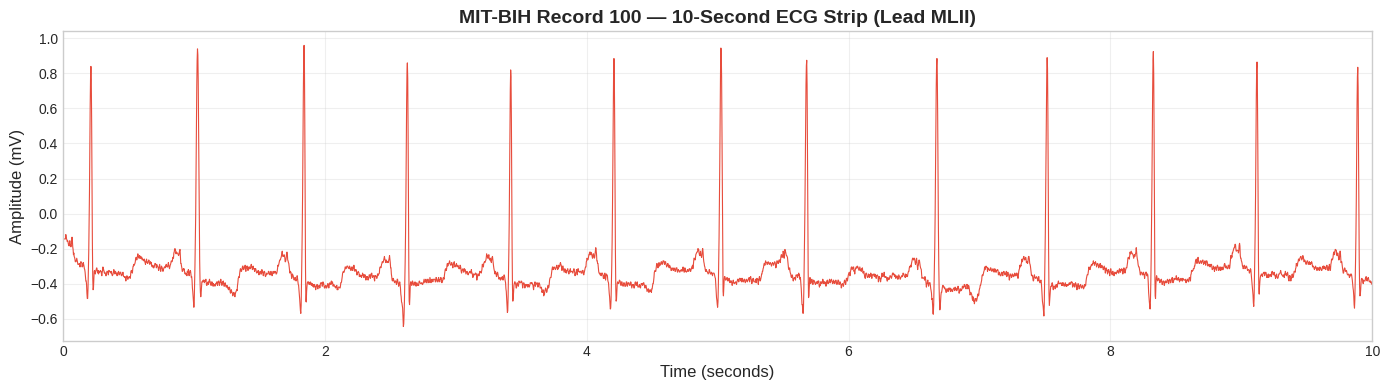

Data source: MIT-BIH PhysioNet
This is exactly the kind of signal the ER doctor's AI must interpret.
Each tall peak is an R-wave — the most prominent feature of a heartbeat.
The AI needs to detect abnormalities in the shape and timing of these waves.


In [17]:
# ============================================================
# Section 7b: Plot a 10-second ECG strip
# ============================================================
fs = record.fs
ecg_signal = record.p_signal[:, 0]  # Channel 0 (MLII)

# Extract 10 seconds of data
n_10sec = int(10 * fs)
ecg_10sec = ecg_signal[:n_10sec]
time_10sec = np.arange(n_10sec) / fs

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_10sec, ecg_10sec, color='#E74C3C', linewidth=0.8)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude (mV)', fontsize=12)
ax.set_title('MIT-BIH Record 100 — 10-Second ECG Strip (Lead MLII)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

source_label = "Synthetic" if USE_SYNTHETIC else "MIT-BIH PhysioNet"
print(f"Data source: {source_label}")
print(f"This is exactly the kind of signal the ER doctor's AI must interpret.")
print(f"Each tall peak is an R-wave — the most prominent feature of a heartbeat.")
print(f"The AI needs to detect abnormalities in the shape and timing of these waves.")


## 8. ECG Annotations — Normal vs Abnormal Beats

Each beat in the MIT-BIH database is **annotated by cardiologists**. These
annotations are the **labels** that supervised machine learning uses to train.

**Common annotation symbols:**
- **N** = Normal beat
- **V** = Ventricular premature beat (PVC) — potentially dangerous
- **A** = Atrial premature beat
- **/** = Paced beat
- **L** = Left bundle branch block beat
- **R** = Right bundle branch block beat

These human expert labels are the "ground truth" for training AI.


In [18]:
# ============================================================
# Section 8: Load and explore annotations
# ============================================================
USE_SYNTHETIC_ANN = False

try:
    ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')
    beat_samples = ann.sample
    beat_symbols = np.array(ann.symbol)
    print(f"Annotations loaded: {len(beat_samples)} annotations")

except Exception as e:
    print(f"Could not load annotations: {e}")
    print("Using synthetic annotations as fallback...")
    USE_SYNTHETIC_ANN = True

    # Generate synthetic annotations at R-peak positions
    period = int(fs * 60 / 72)
    beat_samples = np.arange(int(period * 0.35), record.p_signal.shape[0], period)
    n_beats = len(beat_samples)

    # 90% Normal, 5% V, 3% A, 2% other
    np.random.seed(42)
    symbols = np.array(['N'] * n_beats)
    n_v = int(n_beats * 0.05)
    n_a = int(n_beats * 0.03)
    v_idx = np.random.choice(n_beats, n_v, replace=False)
    remaining = np.setdiff1d(np.arange(n_beats), v_idx)
    a_idx = np.random.choice(remaining, n_a, replace=False)
    symbols[v_idx] = 'V'
    symbols[a_idx] = 'A'
    beat_symbols = symbols

# Print unique beat types and counts
unique, counts = np.unique(beat_symbols, return_counts=True)
print(f"\nBeat type distribution:")
for symbol, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
    pct = count / len(beat_symbols) * 100
    label = {'N': 'Normal', 'V': 'Ventricular premature', 'A': 'Atrial premature',
             '/': 'Paced', 'L': 'Left BBB', 'R': 'Right BBB', '+': 'Rhythm change',
             '~': 'Signal quality change', '|': 'Isolated QRS-like artifact'}.get(symbol, symbol)
    print(f"  {symbol} ({label}): {count:>6} ({pct:.1f}%)")


Annotations loaded: 2274 annotations

Beat type distribution:
  N (Normal):   2239 (98.5%)
  A (Atrial premature):     33 (1.5%)
  + (Rhythm change):      1 (0.0%)
  V (Ventricular premature):      1 (0.0%)


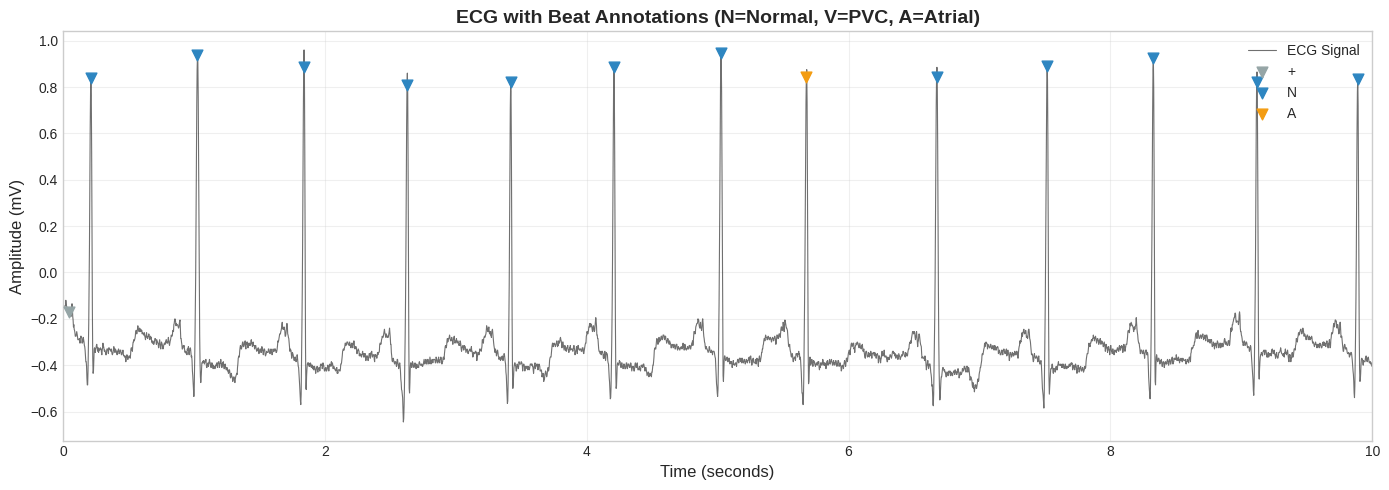

Blue markers (N) = normal beats
Red markers (V) = ventricular premature beats — potentially dangerous
These annotations are the 'labels' that supervised ML uses for training.
A cardiologist spent hours labeling each beat — AI learns from these labels.


In [19]:
# ============================================================
# Section 8b: Plot ECG with annotation overlay
# ============================================================
# Show 10 seconds with colored annotations
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_10sec, ecg_10sec, color='#333333', linewidth=0.8, alpha=0.7,
        label='ECG Signal')

# Overlay annotations within the 10-second window
mask_10sec = beat_samples < n_10sec
ann_samples_10sec = beat_samples[mask_10sec]
ann_symbols_10sec = beat_symbols[mask_10sec]

# Color map for beat types
color_map = {'N': '#2E86C1', 'V': '#E74C3C', 'A': '#F39C12',
             '/': '#9B59B6', 'L': '#E67E22', 'R': '#1ABC9C'}
label_added = set()

for samp, sym in zip(ann_samples_10sec, ann_symbols_10sec):
    if samp < len(ecg_signal):
        color = color_map.get(sym, '#95A5A6')
        lbl = sym if sym not in label_added else None
        ax.scatter(samp / fs, ecg_signal[samp], color=color,
                   s=60, zorder=5, marker='v', label=lbl)
        label_added.add(sym)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude (mV)', fontsize=12)
ax.set_title('ECG with Beat Annotations (N=Normal, V=PVC, A=Atrial)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Blue markers (N) = normal beats")
print("Red markers (V) = ventricular premature beats — potentially dangerous")
print("These annotations are the 'labels' that supervised ML uses for training.")
print("A cardiologist spent hours labeling each beat — AI learns from these labels.")


## 9. ECG Statistics — R-R Intervals and Heart Rate

With the annotation positions, we can compute **R-R intervals** (time between
successive heartbeats) and derive heart rate over time. This is the foundation
of **Heart Rate Variability (HRV)** analysis, which we will explore in depth
in Week 5.

**Clinical significance:**
- Regular R-R intervals = normal sinus rhythm
- Irregular R-R intervals = possible arrhythmia (e.g., atrial fibrillation)
- Very short R-R = premature beat followed by compensatory pause


In [20]:
# ============================================================
# Section 9a: Compute R-R intervals and heart rate
# ============================================================
# Filter to only beat annotations (exclude rhythm change markers etc.)
beat_mask = np.isin(beat_symbols, ['N', 'V', 'A', 'L', 'R', '/'])
beat_positions = beat_samples[beat_mask]

# Compute R-R intervals in seconds
rr_intervals = np.diff(beat_positions) / fs  # in seconds

# Filter out unrealistic intervals (< 0.3s or > 2.0s)
valid_rr = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 2.0)]

# Compute instantaneous heart rate
hr_from_rr = 60.0 / valid_rr  # beats per minute

print("R-R Interval Statistics:")
print(f"  Total beats analyzed: {len(beat_positions)}")
print(f"  Valid RR intervals:   {len(valid_rr)}")
print(f"  Mean RR interval:     {np.mean(valid_rr)*1000:.1f} ms")
print(f"  Std RR interval:      {np.std(valid_rr)*1000:.1f} ms")
print(f"\nHeart Rate Statistics:")
print(f"  Mean HR:  {np.mean(hr_from_rr):.1f} bpm")
print(f"  Std HR:   {np.std(hr_from_rr):.1f} bpm")
print(f"  Min HR:   {np.min(hr_from_rr):.1f} bpm")
print(f"  Max HR:   {np.max(hr_from_rr):.1f} bpm")


R-R Interval Statistics:
  Total beats analyzed: 2273
  Valid RR intervals:   2272
  Mean RR interval:     794.6 ms
  Std RR interval:      48.8 ms

Heart Rate Statistics:
  Mean HR:  75.8 bpm
  Std HR:   5.1 bpm
  Min HR:   53.1 bpm
  Max HR:   114.9 bpm


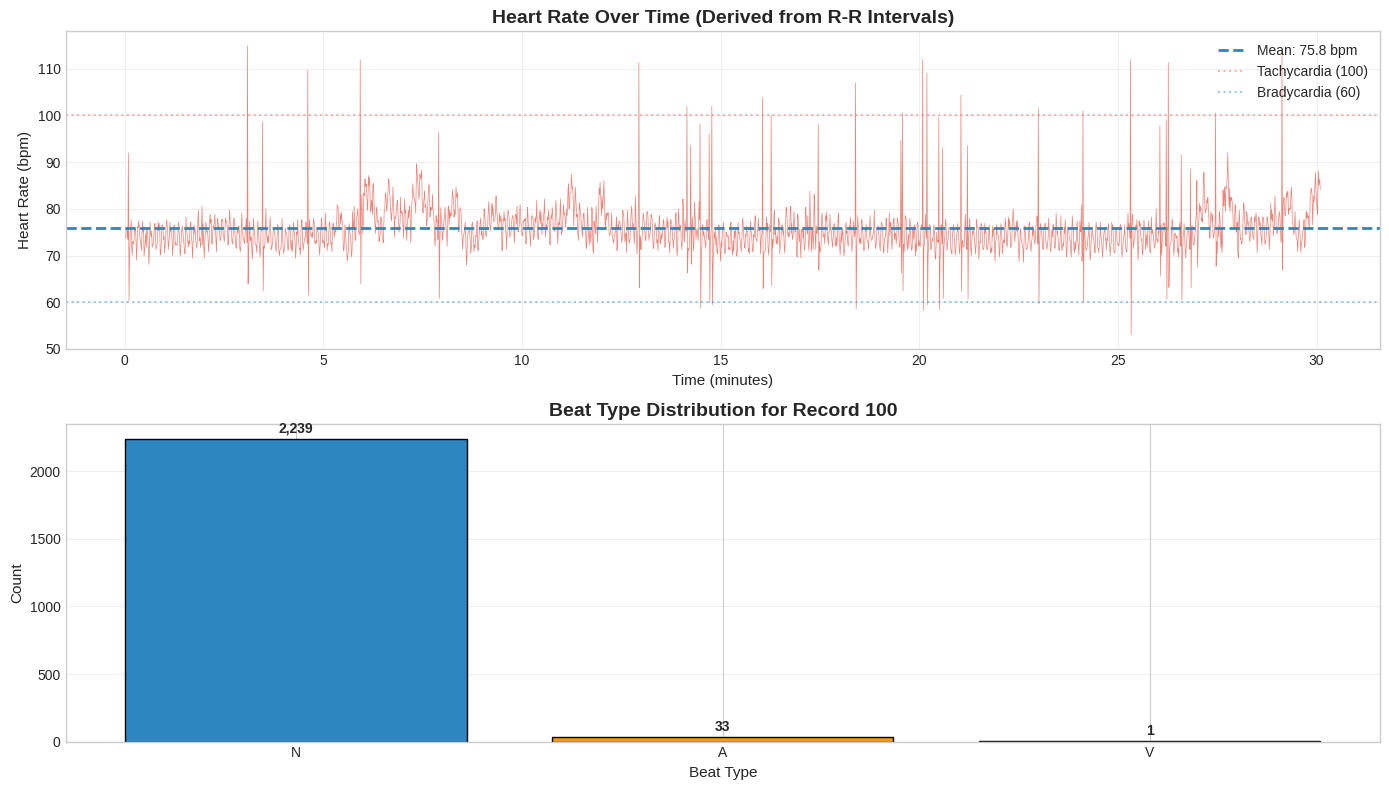

The heart rate plot shows beat-to-beat variability over time.
Sudden spikes or drops may indicate arrhythmia events.
This is exactly the kind of analysis the AI performs in real-time.


In [21]:
# ============================================================
# Section 9b: Plot heart rate over time
# ============================================================
# Time of each HR measurement (midpoint between beats)
hr_times = (beat_positions[1:][
    (rr_intervals > 0.3) & (rr_intervals < 2.0)
]) / fs / 60  # Convert to minutes

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Heart rate trend
axes[0].plot(hr_times, hr_from_rr, color='#E74C3C', linewidth=0.5, alpha=0.7)
axes[0].axhline(y=np.mean(hr_from_rr), color='#2E86C1', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(hr_from_rr):.1f} bpm')
axes[0].axhline(y=100, color='#FF6B6B', linestyle=':', alpha=0.5, label='Tachycardia (100)')
axes[0].axhline(y=60, color='#3498DB', linestyle=':', alpha=0.5, label='Bradycardia (60)')
axes[0].set_xlabel('Time (minutes)', fontsize=11)
axes[0].set_ylabel('Heart Rate (bpm)', fontsize=11)
axes[0].set_title('Heart Rate Over Time (Derived from R-R Intervals)',
                   fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Beat type distribution bar chart
beat_types_filtered = beat_symbols[beat_mask]
unique_types, type_counts = np.unique(beat_types_filtered, return_counts=True)
sort_idx = np.argsort(-type_counts)
unique_types = unique_types[sort_idx]
type_counts = type_counts[sort_idx]

bar_colors = [color_map.get(t, '#95A5A6') for t in unique_types]
bars = axes[1].bar(unique_types, type_counts, color=bar_colors, edgecolor='black')
for bar, count in zip(bars, type_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(type_counts)*0.01,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Beat Type', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Beat Type Distribution for Record 100',
                   fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("The heart rate plot shows beat-to-beat variability over time.")
print("Sudden spikes or drops may indicate arrhythmia events.")
print("This is exactly the kind of analysis the AI performs in real-time.")


## 10. Student Tasks

Complete the following tasks to practice what you have learned. Each task
builds on the skills from this notebook.

| # | Task | Difficulty |
|---|------|------------|
| 1 | Load a different MIT-BIH record (e.g., record 200) and plot it | :star: |
| 2 | Calculate the percentage of abnormal beats in record 100 | :star: |
| 3 | Write a function that takes a record number and returns mean HR | :star::star: |
| 4 | Create a 2x2 subplot comparing ECG from 4 different records | :star::star: |
| 5 | Detect and mark the R-peaks in a 10-second ECG window | :star::star::star: |


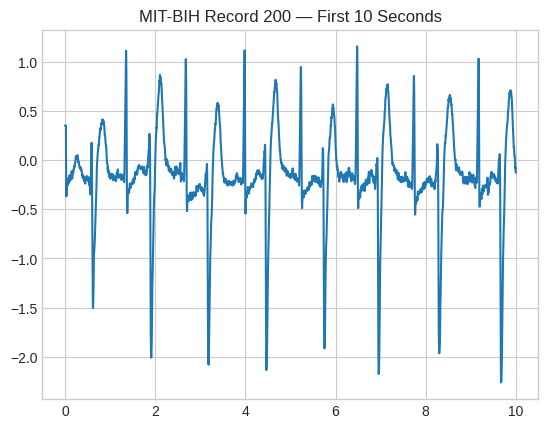

In [30]:
# ============================================================
# Task 1 (Star): Load a different MIT-BIH record and plot it
# ============================================================
# The MIT-BIH database has records: 100-124, 200-234 (not all numbers exist)
# Try loading record 200 which has more arrhythmias

# TODO: Your code here
# Hint:
record_200 = wfdb.rdrecord('200', pn_dir='mitdb')
ecg_200 = record_200.p_signal[:int(10*record_200.fs), 0]
time_200 = np.arange(len(ecg_200)) / record_200.fs
plt.plot(time_200, ecg_200)
plt.title('MIT-BIH Record 200 — First 10 Seconds')
plt.show()




In [31]:
# ============================================================
# Task 2 (Star): Calculate percentage of abnormal beats
# ============================================================
# Using the annotations from record 100 (loaded above),
# calculate what percentage of beats are NOT normal ('N')

# TODO: Your code here
# Hint:
total_beats = len(beat_symbols[beat_mask])
normal_beats = np.sum(beat_symbols[beat_mask] == 'N')
abnormal_pct = (total_beats - normal_beats) / total_beats * 100
print(f"Abnormal beats: {abnormal_pct:.2f}%")




Abnormal beats: 1.50%


In [32]:
# ============================================================
# Task 3 (Star-Star): Function to compute mean HR from any record
# ============================================================
# Write a function that takes a record number (e.g., '100'),
# loads the record and annotations, and returns the mean heart rate.

# TODO: Your code here
# Hint:
def get_mean_hr(record_number):
    try:
        rec = wfdb.rdrecord(record_number, pn_dir='mitdb')
        ann = wfdb.rdann(record_number, 'atr', pn_dir='mitdb')
        rr = np.diff(ann.sample) / rec.fs
        valid = rr[(rr > 0.3) & (rr < 2.0)]
        mean_hr = np.mean(60.0 / valid)
        return mean_hr
    except Exception as e:
        print(f"Error loading record {record_number}: {e}")
        return None

# # Test it
for rec_num in ['100', '101', '102']:
    hr = get_mean_hr(rec_num)
    if hr: print(f"Record {rec_num}: Mean HR = {hr:.1f} bpm")




Record 100: Mean HR = 75.8 bpm
Record 101: Mean HR = 62.4 bpm
Record 102: Mean HR = 73.1 bpm


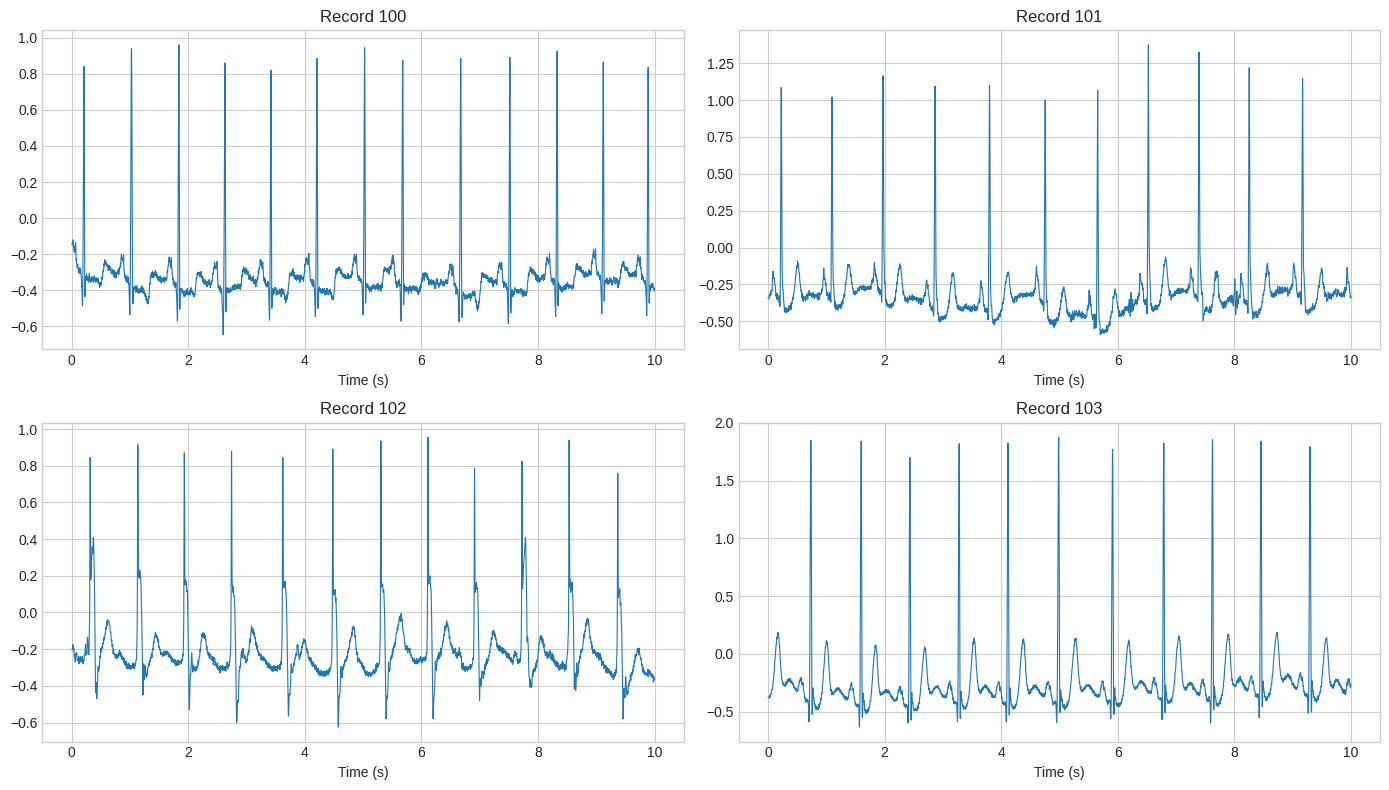

In [33]:
# ============================================================
# Task 4 (Star-Star): 2x2 subplot comparing 4 records
# ============================================================
# Load 4 different MIT-BIH records and plot 10 seconds from each
# in a 2x2 grid. Add titles with the record number.

# TODO: Your code here
# Hint:
records = ['100', '101', '102', '103']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, rec_num in zip(axes.flatten(), records):
    try:
        rec = wfdb.rdrecord(rec_num, pn_dir='mitdb')
        ecg_seg = rec.p_signal[:int(10*rec.fs), 0]
        t = np.arange(len(ecg_seg)) / rec.fs
        ax.plot(t, ecg_seg, linewidth=0.8)
        ax.set_title(f'Record {rec_num}')
        ax.set_xlabel('Time (s)')
    except: ax.set_title(f'Record {rec_num} (failed)')
plt.tight_layout()
plt.show()




Detected 13 R-peaks in 10 seconds
Estimated HR: 78 bpm


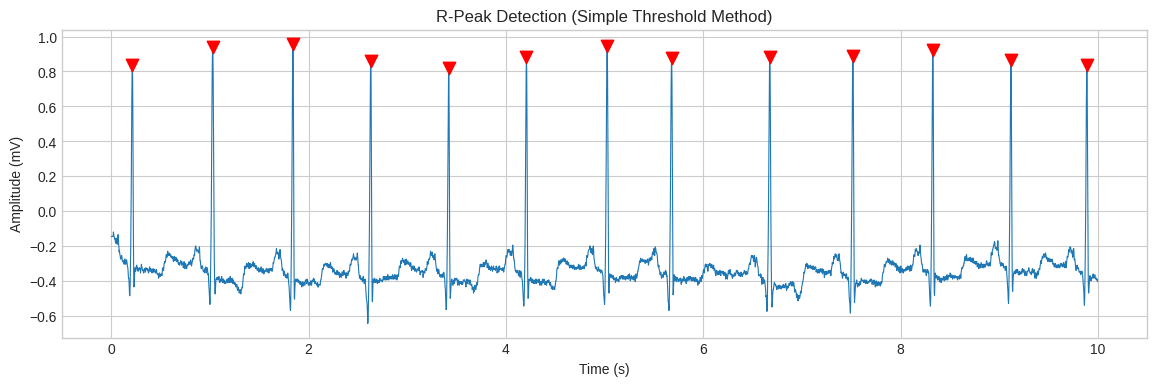

In [34]:
# ============================================================
# Task 5 (Star-Star-Star): Detect R-peaks in a 10-second window
# ============================================================
# Implement a simple R-peak detector using a threshold approach:
# 1. Take the first 10 seconds of ECG from record 100
# 2. Find all local maxima above a threshold (e.g., 0.5 * max amplitude)
# 3. Ensure minimum distance between peaks (e.g., 0.3 seconds)
# 4. Plot the ECG with detected R-peaks marked

# TODO: Your code here
# Hint:
from scipy.signal import find_peaks
ecg_seg = ecg_signal[:n_10sec]
threshold = 0.5 * np.max(ecg_seg)
min_distance = int(0.3 * fs)  # 0.3 seconds minimum between peaks
peaks, properties = find_peaks(ecg_seg, height=threshold, distance=min_distance)
print(f"Detected {len(peaks)} R-peaks in 10 seconds")
print(f"Estimated HR: {len(peaks) * 6:.0f} bpm")  # 10s * 6 = 60s

plt.figure(figsize=(14, 4))
plt.plot(time_10sec, ecg_seg, linewidth=0.8)
plt.scatter(peaks / fs, ecg_seg[peaks], color='red', s=80, marker='v', zorder=5)
plt.title('R-Peak Detection (Simple Threshold Method)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.show()




## 11. Gemini AI Exercise

Use Gemini to learn more about the dataset and ECG fundamentals. These
prompts help you connect the technical work above to clinical knowledge.


In [27]:
# ============================================================
# Section 11a: Ask Gemini about MIT-BIH database history
# ============================================================
try:
    from google.colab import ai

    print("Gemini: History of the MIT-BIH Database")
    print("=" * 50)
    response = ai.generate_text(
        "Tell me the history of the MIT-BIH Arrhythmia Database. "
        "Who created it, when, and why is it important for medical AI? "
        "How many papers have cited it? Keep it under 200 words."
    )
    print(response)

except Exception as e:
    print(f"Gemini not available: {e}")
    print("\nKey facts about MIT-BIH Arrhythmia Database:")
    print("  - Created in 1980 by MIT and Beth Israel Hospital (Boston)")
    print("  - 48 half-hour 2-channel ambulatory ECG recordings")
    print("  - 47 subjects studied (25 men aged 32-89, 22 women aged 23-89)")
    print("  - Over 110,000 beats annotated by cardiologists")
    print("  - Available on PhysioNet (physionet.org)")
    print("  - Cited by 10,000+ research papers")
    print("  - Still the most commonly used benchmark for arrhythmia detection")
    print("  - Helped establish PhysioNet as the go-to resource for physiological signals")


Gemini: History of the MIT-BIH Database
The MIT-BIH Arrhythmia Database, a landmark resource, was developed collaboratively by the Massachusetts Institute of Technology (MIT) and Beth Israel Hospital in the late 1970s and early 1980s, becoming publicly available around 1983. Key contributors included Roger G. Mark and George B. Moody.

Its importance for medical AI is profound. It comprises 48 half-hour, two-channel ambulatory ECG recordings from 47 subjects, meticulously annotated by expert cardiologists with detailed beat and rhythm classifications. This standardized, publicly accessible dataset established a crucial, unbiased benchmark for developing, testing, and comparing algorithms for automated arrhythmia detection and ECG analysis.

By providing a common ground for performance evaluation, it significantly accelerated research in cardiac AI, leading to advancements in diagnostic tools and wearable health technology. It has been cited in thousands of research papers, solidifying 

In [28]:
# ============================================================
# Section 11b: Ask Gemini to explain ECG features
# ============================================================
try:
    from google.colab import ai

    print("\nGemini: ECG Wave Components")
    print("=" * 50)
    response = ai.generate_text(
        "Explain the P wave, QRS complex, and T wave in an ECG signal "
        "for a biomedical engineering student. What does each represent "
        "electrically and mechanically in the heart? What does an "
        "abnormal QRS complex look like and what could it indicate? "
        "Keep it under 250 words."
    )
    print(response)

except Exception as e:
    print(f"Gemini not available: {e}")
    print("\nECG Wave Components:")
    print("  P Wave:")
    print("    - Electrical: Atrial depolarization (SA node fires)")
    print("    - Mechanical: Atria contract, pushing blood into ventricles")
    print("    - Duration: ~0.08-0.10 seconds")
    print("  QRS Complex:")
    print("    - Electrical: Ventricular depolarization")
    print("    - Mechanical: Ventricles contract, pumping blood to body/lungs")
    print("    - Duration: ~0.06-0.10 seconds (wider = abnormal)")
    print("    - The R-peak is the tallest point - used for heart rate calculation")
    print("  T Wave:")
    print("    - Electrical: Ventricular repolarization (recovery)")
    print("    - Mechanical: Ventricles relax, refill with blood")
    print("  ST Segment (between S and T):")
    print("    - Normally at baseline (isoelectric)")
    print("    - ST ELEVATION = possible STEMI (heart attack!)")
    print("    - This is what the AI in our clinical scenario detects")



Gemini: ECG Wave Components
The ECG visually represents the heart's electrical activity.

The **P wave** signifies **atrial depolarization** (electrical activation of the atria as the SA node fires). Mechanically, this initiates **atrial contraction (systole)**, pushing blood into the ventricles.

The **QRS complex** represents **ventricular depolarization** (electrical activation of the ventricles). Atrial repolarization also occurs here but is usually masked. Mechanically, this triggers **ventricular contraction (systole)**, ejecting blood to the pulmonary and systemic circulations.

The **T wave** indicates **ventricular repolarization** (electrical recovery of the ventricles). Mechanically, this allows the ventricles to **relax (diastole)** and refill with blood.

An **abnormal QRS complex** is typically **widened (>0.12s)**, **notched**, or has a **bizarre morphology**. Electrically, this suggests **delayed or aberrant conduction** through the ventricles, often bypassing normal, 

## 12. Summary & Self-Check

### Key Takeaways

1. **Google Colab** is your browser-based Python lab — markdown cells document, code cells compute
2. **Python fundamentals** (variables, lists, functions, dicts) are the building blocks of medical AI
3. **NumPy** enables fast array operations on patient data (1D signals to 4D image batches)
4. **matplotlib** creates clinical visualizations — from vital sign trends to ECG strips
5. **MIT-BIH Arrhythmia Database** is a cornerstone of medical AI, containing 110,000+ annotated ECG beats
6. **Annotations (labels)** from cardiologists are the "ground truth" that supervised ML learns from

### Self-Check Checklist

- [ ] I can create and run cells in Google Colab
- [ ] I understand Python basics: variables, lists, functions, dictionaries
- [ ] I can use NumPy for array operations and statistics
- [ ] I can create clinical visualizations with matplotlib
- [ ] I loaded and plotted real ECG data from MIT-BIH
- [ ] I can identify normal vs abnormal beats in ECG annotations

### Action Items for Next Week
- [ ] Create a GitHub account and apply for the Student Developer Pack
- [ ] Explore 2-3 different MIT-BIH records on your own
- [ ] Try the student tasks (especially Tasks 1-3)

### Next Week Preview
**Week 2: Digital Health and AI Fundamentals** — deeper dive into the AI hierarchy
(AI vs ML vs DL), the full digital health landscape, and your first classifier
on a medical dataset. The Python and NumPy skills from today will be essential!


In [29]:
# ============================================================
# Final verification: did everything run?
# ============================================================
print("=" * 60)
print("Congratulations! You have completed the Week 1 Notebook!")
print("Course Introduction: Digital Health and AI")
print("=" * 60)

source_label = "Synthetic" if USE_SYNTHETIC else "MIT-BIH PhysioNet"
print(f"\nECG Data Source: {source_label}")
print(f"  Signal shape:  {record.p_signal.shape}")
print(f"  Sampling rate: {record.fs} Hz")
print(f"  Total beats:   {len(beat_samples)}")

print(f"\nHeart Rate (from R-R intervals):")
print(f"  Mean: {np.mean(hr_from_rr):.1f} bpm")
print(f"  Std:  {np.std(hr_from_rr):.1f} bpm")
print(f"  Range: {np.min(hr_from_rr):.1f} - {np.max(hr_from_rr):.1f} bpm")

print(f"\nSkills practiced today:")
print(f"  1. Google Colab: markdown + code cells")
print(f"  2. Python: variables, lists, functions, dictionaries")
print(f"  3. NumPy: arrays, statistics, boolean indexing")
print(f"  4. matplotlib: line plots, subplots, bar charts, scatter plots")
print(f"  5. wfdb: loading real ECG data from PhysioNet")
print(f"  6. Clinical context: vitals, BMI, BP classification, ECG annotations")

print(f"\nReturning to the clinical scenario:")
print(f"  The ER doctor's phone app that detects STEMI in 10 seconds uses")
print(f"  exactly the kind of ECG data you just loaded and visualized.")
print(f"  Over the coming weeks, you will learn to BUILD that AI yourself.")

print(f"\nNext week: Digital Health and AI Fundamentals")
print(f"  Your first ML classifier on a medical dataset!")


Congratulations! You have completed the Week 1 Notebook!
Course Introduction: Digital Health and AI

ECG Data Source: MIT-BIH PhysioNet
  Signal shape:  (650000, 2)
  Sampling rate: 360 Hz
  Total beats:   2274

Heart Rate (from R-R intervals):
  Mean: 75.8 bpm
  Std:  5.1 bpm
  Range: 53.1 - 114.9 bpm

Skills practiced today:
  1. Google Colab: markdown + code cells
  2. Python: variables, lists, functions, dictionaries
  3. NumPy: arrays, statistics, boolean indexing
  4. matplotlib: line plots, subplots, bar charts, scatter plots
  5. wfdb: loading real ECG data from PhysioNet
  6. Clinical context: vitals, BMI, BP classification, ECG annotations

Returning to the clinical scenario:
  The ER doctor's phone app that detects STEMI in 10 seconds uses
  exactly the kind of ECG data you just loaded and visualized.
  Over the coming weeks, you will learn to BUILD that AI yourself.

Next week: Digital Health and AI Fundamentals
  Your first ML classifier on a medical dataset!
